In [1]:
import pandas as pd
import numpy as np

# خواندن داده‌ها از فایل CSV
df = pd.read_excel("language.harvard.xlsx")  # نام فایل را جایگزین کن

# استخراج لیست یکتای کشورها
countries = sorted(set(df['country_i'].unique()).union(df['country_j'].unique()))

# ساخت ماتریس صفر
W = pd.DataFrame(0, index=countries, columns=countries)

# مقداردهی به ماتریس
for _, row in df.iterrows():
    i = row['country_i']
    j = row['country_j']
    W.loc[i, j] = row['lps']

# اگر بخواهی ماتریس ردیف‌نرمال شود:
W_normalized_lan = W.div(W.sum(axis=1), axis=0)

# یا ذخیره:
W_normalized_lan.to_csv("spatial_weight_matrix.csv")


W_normalized_lan

<ipython-input-1-3771898118>:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0733273538052212' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
<ipython-input-1-3771898118>:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0032534563453104' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
<ipython-input-1-3771898118>:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0440477415584526' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  W.loc[i, j] = row['lps']
<ipython-input-1-3771898118>:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will rai

,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.040747,0.001808,0.024477,0.017848,0.083947,0.129231,0.093262,0.144250,0.163088,0.004046,0.297297
China,0.006044,0.940691,0.000082,0.000599,0.006947,0.001242,0.000326,0.011200,0.027350,0.000018,0.005501
Egypt,0.008460,0.000009,0.352654,0.010165,0.013634,0.018848,0.017599,0.019450,0.007498,0.542292,0.009393
Georgia,0.037687,0.000378,0.062101,0.094667,0.209601,0.143353,0.232784,0.093288,0.048146,0.010155,0.067840
India,0.067721,0.001676,0.031822,0.080075,0.265827,0.147740,0.141520,0.164254,0.060096,0.016491,0.022778
Iran,0.124732,0.000359,0.052634,0.065526,0.176765,0.128629,0.108728,0.144686,0.073574,0.037582,0.086785
Italy,0.075559,0.000079,0.041253,0.089315,0.142131,0.091267,0.286468,0.185267,0.067071,0.006687,0.014903
Kazakhstan,0.106023,0.002462,0.041362,0.032471,0.149653,0.110179,0.168074,0.057249,0.227530,0.006517,0.098479
Kyrgyzstan,0.167267,0.008391,0.022249,0.023385,0.076405,0.078182,0.084907,0.317501,0.062183,0.003487,0.156045
Saudi Arabia,0.001273,0.000002,0.493501,0.001513,0.006430,0.012247,0.002596,0.002789,0.001069,0.469265,0.009316


In [4]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# خواندن فایل اکسل
df = pd.read_excel('religous.xlsx')

# ستون‌هایی که شامل تعداد جمعیت هر دین هستن
religion_cols = ['Christians', 'Muslims', 'Unaffiliated', 'Hindus', 'Buddhists', 'Other religions', 'Jews']

# فرض می‌کنیم داده‌های کمتر از 10000 را 5000 گذاشته‌ای (اگر لازم بود در همین کد هم میشه اعمال کرد)

# نرمال‌سازی سطری: هر مقدار تقسیم بر مجموع آن ردیف
df[religion_cols] = df[religion_cols].div(df[religion_cols].sum(axis=1), axis=0)

# استخراج وکتورهای دینی
vectors = df[religion_cols].values

# محاسبه شباهت کسینوس




from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix  = cosine_similarity(vectors)
np.fill_diagonal(similarity_matrix , 1.0)  # ensure self-similarity is max



W_religion_normalized = similarity_matrix

W_religion_normalized



array([[1.        , 0.02920859, 0.99926333, 0.13765251, 0.17644012,
        0.99981883, 0.0562322 , 0.93669595, 0.99770559, 0.99956531,
        0.99989479],
       [0.02920859, 1.        , 0.01893784, 0.03412088, 0.00560996,
        0.01763487, 0.10296885, 0.06393507, 0.03772333, 0.01929981,
        0.01963712],
       [0.99926333, 0.01893784, 1.        , 0.17383371, 0.1767488 ,
        0.99864642, 0.09186093, 0.94850257, 0.99936461, 0.99961321,
        0.9988871 ],
       [0.13765251, 0.03412088, 0.17383371, 1.        , 0.05086816,
        0.12238913, 0.99413599, 0.47478538, 0.20407922, 0.15585807,
        0.12744481],
       [0.17644012, 0.00560996, 0.1767488 , 0.05086816, 1.        ,
        0.17556205, 0.03862531, 0.17397172, 0.17818715, 0.19699318,
        0.17602657],
       [0.99981883, 0.01763487, 0.99864642, 0.12238913, 0.17556205,
        1.        , 0.0401115 , 0.93086538, 0.99641562, 0.99920869,
        0.99997975],
       [0.0562322 , 0.10296885, 0.09186093, 0.99413599, 0.

In [9]:
alpha = 0.5 # وزن زبان

W_combined = alpha * W_normalized_lan + (1 - alpha) * W_religion_normalized

import numpy as np

# صفر کردن قطر اصلی (diagonal) ماتریس
np.fill_diagonal(W_combined.values, 0)


# ردیف‌نرمال کردن
W_combined_normalized = W_combined.div(W_combined.sum(axis=1), axis=0)
W_combined_normalized = W_combined.div(W_combined.sum(axis=1), axis=0)


import numpy as np
import pandas as pd

# فرض: W_combined قبلاً ساخته شده
W_cleaned = W_combined.copy()
np.fill_diagonal(W_cleaned.values, 0)

# نرمال‌سازی ردیفی
W_combined_normalized = W_cleaned.div(W_cleaned.sum(axis=1), axis=0)

W_combined_normalized

,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.004254,0.140397,0.021326,0.035710,0.154840,0.020502,0.148243,0.159193,0.137637,0.177899
China,0.086321,0.000000,0.046574,0.085016,0.030748,0.046224,0.252935,0.183980,0.159343,0.047304,0.061554
Egypt,0.142879,0.002686,0.000000,0.026088,0.026993,0.144264,0.015520,0.137240,0.142756,0.218617,0.142957
Georgia,0.051868,0.010205,0.069793,0.000000,0.077050,0.078610,0.362940,0.168044,0.074612,0.049109,0.057768
India,0.117204,0.003498,0.100120,0.062857,0.000000,0.155194,0.086475,0.162358,0.114383,0.102479,0.095432
Iran,0.157236,0.002516,0.146991,0.026274,0.049263,0.000000,0.020811,0.150385,0.149607,0.144965,0.151953
Italy,0.049128,0.038414,0.049622,0.403883,0.067381,0.048974,0.000000,0.219011,0.071105,0.030029,0.022453
Kazakhstan,0.135292,0.008615,0.128434,0.065816,0.041990,0.135074,0.073999,0.000000,0.153853,0.123126,0.133802
Kyrgyzstan,0.156824,0.006208,0.137526,0.030620,0.034272,0.144658,0.028079,0.171736,0.000000,0.134878,0.155198
Saudi Arabia,0.144726,0.002791,0.215911,0.022757,0.029416,0.146261,0.011057,0.136685,0.144536,0.000000,0.145860


In [10]:
import pandas as pd

# خواندن فایل CSV
df_sorted = pd.read_excel('FINAL_WIDE_W_14020317.xlsx')

# نمایش چند سطر اول برای اطمینان از درست خواندن
df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0
...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_sorted['ps_x_unesco_scaled'] = scaler.fit_transform(df_sorted[['politunesco']])

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


# نرمال‌سازی تعداد سایت‌های یونسکو به بازه [0,1]
df_sorted['unesco_scaled'] = scaler.fit_transform(df_sorted[['unesco']])

df_sorted['rulelaw_scaled'] = (df_sorted['Rule of Law: Estimate'] - df_sorted['Rule of Law: Estimate'].mean()) / df_sorted['Rule of Law: Estimate'].std()

df_sorted['unesco_x_rulelaw'] = df_sorted['unesco_scaled'] * df_sorted['rulelaw_scaled']



df_sorted



df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco,ps_x_unesco_scaled,unesco_scaled,rulelaw_scaled,unesco_x_rulelaw
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0,0.191522,0.035088,-1.100855,-0.038626
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0,0.252385,0.035088,-0.944155,-0.033128
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0,0.223744,0.035088,-0.983330,-0.034503
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0,0.207377,0.035088,-0.767868,-0.026943
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0,0.215560,0.035088,-0.963743,-0.033816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0,-0.116882,0.087719,0.329030,0.028862
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0,-0.326576,0.087719,0.113568,0.009962
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0,-0.236049,0.087719,0.152743,0.013398
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0,-0.043233,0.087719,0.015630,0.001371


In [12]:
W = W_combined_normalized  # ماتریس وزن ثابت N×N
W

,Azerbaijan,China,Egypt,Georgia,India,Iran,Italy,Kazakhstan,Kyrgyzstan,Saudi Arabia,Türkiye
Azerbaijan,0.000000,0.004254,0.140397,0.021326,0.035710,0.154840,0.020502,0.148243,0.159193,0.137637,0.177899
China,0.086321,0.000000,0.046574,0.085016,0.030748,0.046224,0.252935,0.183980,0.159343,0.047304,0.061554
Egypt,0.142879,0.002686,0.000000,0.026088,0.026993,0.144264,0.015520,0.137240,0.142756,0.218617,0.142957
Georgia,0.051868,0.010205,0.069793,0.000000,0.077050,0.078610,0.362940,0.168044,0.074612,0.049109,0.057768
India,0.117204,0.003498,0.100120,0.062857,0.000000,0.155194,0.086475,0.162358,0.114383,0.102479,0.095432
Iran,0.157236,0.002516,0.146991,0.026274,0.049263,0.000000,0.020811,0.150385,0.149607,0.144965,0.151953
Italy,0.049128,0.038414,0.049622,0.403883,0.067381,0.048974,0.000000,0.219011,0.071105,0.030029,0.022453
Kazakhstan,0.135292,0.008615,0.128434,0.065816,0.041990,0.135074,0.073999,0.000000,0.153853,0.123126,0.133802
Kyrgyzstan,0.156824,0.006208,0.137526,0.030620,0.034272,0.144658,0.028079,0.171736,0.000000,0.134878,0.155198
Saudi Arabia,0.144726,0.002791,0.215911,0.022757,0.029416,0.146261,0.011057,0.136685,0.144536,0.000000,0.145860


In [13]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# فرض: df_sorted، X، y، W_dict، countries و years از قبل آماده‌سازی شده‌اند.
# فرض می‌کنیم X ماتریس متغیرهای مستقل است، مثلاً:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate',"Rule of Law: Estimate"]].values


K = X.shape[1]  # تعداد متغیرهای مستقل
N = df_sorted.shape[0]  # تعداد کل ردیف‌های داده (نمونه‌ها)
y = df_sorted['inbound'].values


# نگاشت ایندکس‌ها
country_to_idx = {c: i for i, c in enumerate(sorted(df_sorted['country'].unique()))}
year_to_idx = {y: i for i, y in enumerate(sorted(df_sorted['year'].unique()))}

N = len(country_to_idx)
T = len(year_to_idx)
K = X.shape[1]

# ساخت Wy و WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # ماتریس وزنی سال

    # مقادیر y سال جاری
    df_year = df_sorted[df_sorted['year'] == year].set_index('country')

    # اطمینان از اینکه همه کشورها با ترتیب countries_sorted در ایندکس هستند
    # و جای خالی‌ها را با 0 پر می‌کنیم
    countries_sorted = sorted(df_sorted['country'].unique()) # Define countries_sorted here
    df_year = df_year.reindex(countries_sorted, fill_value=0)

    y_t = df_year['inbound'].values

    # محاسبه Wy برای کشور c_idx در سال y_idx
    # از iloc برای دسترسی به سطر ماتریس W بر اساس موقعیت عددی استفاده می‌کنیم
    wy = np.dot(W.iloc[c_idx], y_t)
    y_neighbors.append(wy)

    # WX
    X_t = X[y_idx * N:(y_idx + 1) * N]
    WX[obs_idx] = np.dot(W.iloc[c_idx], X_t) # همچنین از iloc برای دسترسی به سطر ماتریس W استفاده می‌کنیم

y_neighbors = np.array(y_neighbors)

# ایندکس کشورها برای اثرات ثابت
country_idx = pd.Categorical(df_sorted['country']).codes

# ✅ ساخت مدل بیزین SDM با PyMC
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    # مدل خطی فضایی
    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    # مدل نرمال برای متغیر وابسته
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)


 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.01        383          20.42 draws/s    0:01:37   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.01        191          10.25 draws/s    0:03:14   0:00:00

             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
rho        0.6543  0.0921  0.4747   0.8162     0.0028   0.0022  1062.6555   
beta[0]    0.4294  0.1670  0.1221   0.7414     0.0051   0.0038  1079.7965   
beta[1]    0.4007  0.1171  0.1656   0.6026     0.0028   0.0025  1769.5256   
beta[2]    0.1352  0.0781 -0.0031   0.2939     0.0023   0.0019  1170.3962   
beta[3]    0.4385  0.1771  0.0717   0.7408     0.0046   0.0044  1506.7126   
gamma[0]   0.1698  0.0852  0.0202   0.3412     0.0022   0.0019  1533.0426   
gamma[1]   0.0144  0.1430 -0.2539   0.2724     0.0037   0.0032  1506.7623   
gamma[2]   0.0384  0.0340 -0.0244   0.1030     0.0009   0.0007  1579.0974   
gamma[3]   0.2518  0.1553 -0.0357   0.5448     0.0042   0.0034  1397.4570   
sigma      0.3810  0.0202  0.3445   0.4190     0.0005   0.0005  2039.1487   
alpha[0]  -0.8385  0.3795 -1.5321  -0.0982     0.0152   0.0092   626.0151   
alpha[1]   3.0434  0.3202  2.4439   3.6165     0.0135   0.0079   561.8905   

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.6543,0.0921,0.4747,0.8162,0.0028,0.0022,1062.6555,1102.0886,1.0047
beta[0],0.4294,0.1670,0.1221,0.7414,0.0051,0.0038,1079.7965,1105.7629,1.0019
beta[1],0.4007,0.1171,0.1656,0.6026,0.0028,0.0025,1769.5256,1601.1199,1.0021
beta[2],0.1352,0.0781,-0.0031,0.2939,0.0023,0.0019,1170.3962,1055.3414,1.0005
beta[3],0.4385,0.1771,0.0717,0.7408,0.0046,0.0044,1506.7126,1329.6307,0.9994
gamma[0],0.1698,0.0852,0.0202,0.3412,0.0022,0.0019,1533.0426,1293.1634,1.0002
gamma[1],0.0144,0.1430,-0.2539,0.2724,0.0037,0.0032,1506.7623,1284.9968,0.9996
gamma[2],0.0384,0.0340,-0.0244,0.1030,0.0009,0.0007,1579.0974,1453.1058,1.0006
gamma[3],0.2518,0.1553,-0.0357,0.5448,0.0042,0.0034,1397.4570,1282.4157,1.0014
sigma,0.3810,0.0202,0.3445,0.4190,0.0005,0.0005,2039.1487,1420.1406,0.9994


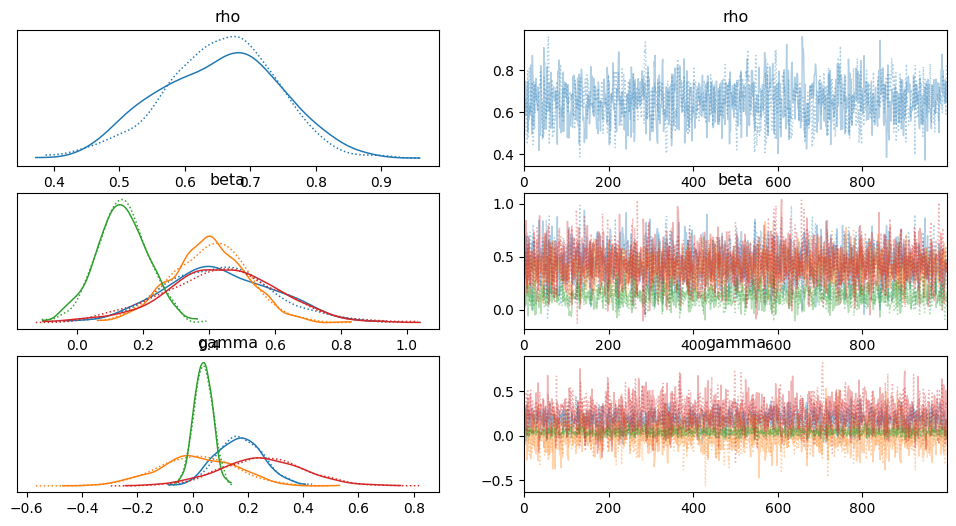

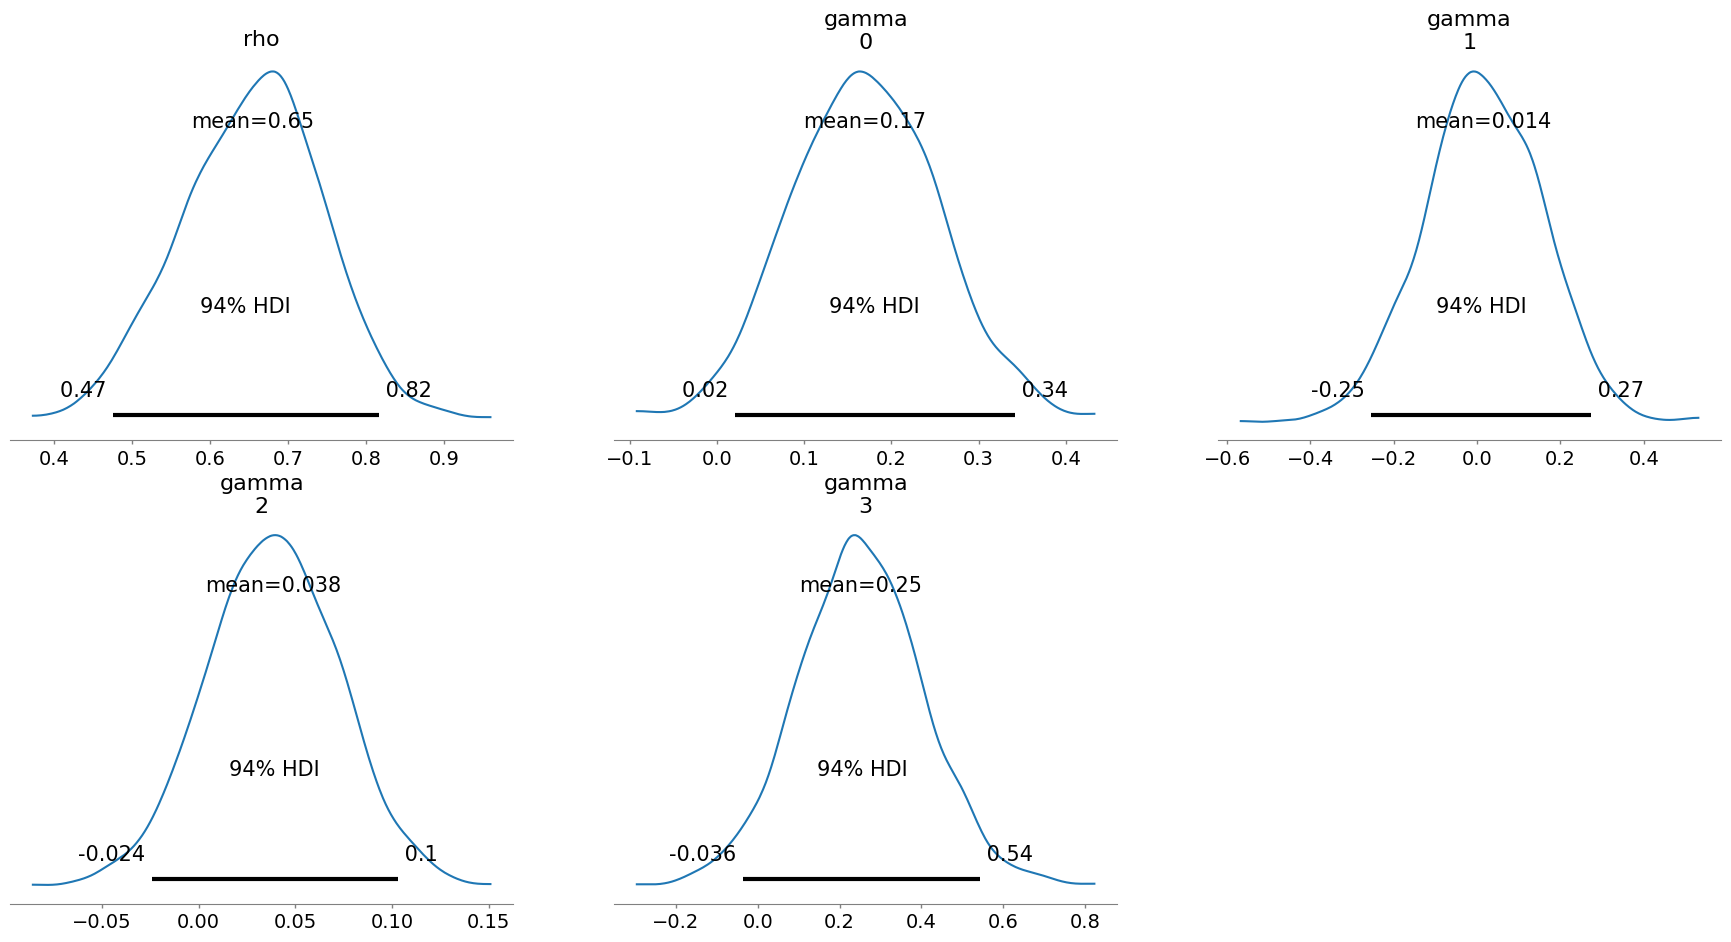

In [14]:
# خلاصه پارامترها
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"], round_to=4)
print(summary)

# نمودارهای تشخیصی
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])
summary

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# داده‌ها: df_sorted و ستون‌های X که انتخاب کردی
X_df = df_sorted[['GDP', 'Political Stability', 'exchange rate', "Airtran", "Rule of Law: Estimate", "unesco_x_rulelaw"]]

# محاسبه ماتریس همبستگی
corr_matrix = X_df.corr()
print("Correlation matrix:")
print(corr_matrix)

# محاسبه VIF
# ابتدا باید آرایه numpy
X_np = X_df.values

vif_data = pd.DataFrame()
vif_data["feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_np, i) for i in range(X_np.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print(vif_data)


In [ ]:
with pm.Model() as sdm_model:
    # priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    mu = (pm.math.dot(X, beta)
          + pm.math.dot(WX, gamma)
          + alpha[country_idx]
          + rho * y_neighbors)

    # تعریف متغیر مشاهده
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # محاسبه لاگ‌لایکلی‌هود هر نمونه (برای هر داده)
    log_likelihood = pm.Deterministic(
        "log_likelihood",
        pm.Normal.dist(mu=mu, sigma=sigma).logp(y)
    )

    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)


In [ ]:
import numpy as np
import arviz as az

# Extract log likelihood
log_likelihood = az.extract_log_likelihood(trace, var_name="y_obs")

# log_likelihood.shape = (n_samples, n_observations)
# میانگین log likelihood بر روی نمونه‌ها و سپس جمع روی مشاهدات
mean_ll_per_obs = np.mean(log_likelihood, axis=0)  # میانگین برای هر مشاهده
ll = np.sum(mean_ll_per_obs)  # مجموع روی تمام مشاهدات

# تعداد پارامترها: beta + gamma + alpha + rho + sigma
# beta و gamma هرکدام K پارامتر دارند، alpha هم N پارامتر، rho و sigma هرکدام 1 پارامتر
K_total = 2*K + N + 2

# تعداد مشاهدات
n = len(y)

# محاسبه AIC و BIC
AIC = 2 * K_total - 2 * ll
BIC = K_total * np.log(n) - 2 * ll

print("AIC:", AIC)
print("BIC:", BIC)


In [ ]:
import numpy as np

# فرض: ll = مقدار log-likelihood
#       k = تعداد پارامترها (از جمله intercept)
#       n = تعداد مشاهدات

AIC = 2 * K - 2 * ll
BIC = K * np.log(n) - 2 * ll

print("AIC:", AIC)
print("BIC:", BIC)
